In [ ]:
# This document calculate SHAP values
# ** SHAP explains how the predictive model makes its decisions by assigning an importance value to each feature for a given prediction. It helps us understand which features are driving the model's predictions and how they contribute to the final output. **

In [2]:
# prepare data
import pandas as pd

df = pd.read_csv(
    r"C:\Users\papak\_Study\DSI\ds_team2_bank_marketing\data\raw\bank-additional-full.csv",
    sep = ";")

In [3]:
# display first 10 rows of df
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import shap
import numpy as np
import random

np.random.seed(42)
random.seed(42)


c:\Users\papak\_Study\DSI\ds_team2_bank_marketing\production-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Convert target variable to binary
df['y_binary'] = df['y'].map({'yes':1, 'no':0})

In [6]:
# Define feature matrix and target vector
X = df.drop(columns=['y', 'y_binary']) 
y = df['y_binary']

In [7]:
# Identify numeric and categorical columns
num_cols = [ 'age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed' ]
cat_cols = [ 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome' ]

In [8]:
# Build preprocessing pipelines
# -numeric features: standard scaling
# -categorical features: one-hot encoding

pipe_numeric = Pipeline([('scaler', StandardScaler())])
pipe_categorical = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

# Combine numeric + categorical preprocessing
preproc = ColumnTransformer([
    ('num', pipe_numeric, num_cols),
    ('cat', pipe_categorical, cat_cols)
])


In [9]:
# Build model pipeline (preprocessing + Random Forest)
pipe_rf = Pipeline([
    ('preprocessing', preproc),
    ('classifier', RandomForestClassifier(random_state=42)) # for reproducibility
])


In [10]:
y.value_counts(normalize=True)

y_binary
0    0.887346
1    0.112654
Name: proportion, dtype: float64

Since "yes" < 15%, stratification is recommended to ensure the model sees enough examples of the minority class in both train and test sets, which can improve performance and SHAP explanations.

In [11]:
# Train-test split -- prevent data leakage for SHAP analysis


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y) 
# stratify=y ensures the same class distribution in train and test sets
# it forces the train and test sets to have the same proportion of "yes" and "no" as the original dataset, which is important for model performance and SHAP analysis.


In [12]:
# Hyperparamter tuning with GridSearchCV
# - Tune n_estimators and max_depth for Random Forest

param_grid_rf = {
    'classifier__n_estimators': [200, 300, 400],
    'classifier__max_depth': [5, 10, 15]
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    refit=True
)

grid_rf.fit(X_train, y_train)

best_model = grid_rf.best_estimator_
print("Best parameters:", grid_rf.best_params_)



Best parameters: {'classifier__max_depth': 15, 'classifier__n_estimators': 200}


In [14]:
from sklearn.metrics import roc_auc_score
# Cacluate ROC-AUC for Random Forest
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict_proba(X_test)[:, 1] 
rf_auc = roc_auc_score(y_test, y_pred_rf) 
print("Random Forest test ROC-AUC:", rf_auc)

Random Forest test ROC-AUC: 0.9496731862351997


In [17]:
# Extract preprocessing + model for SHAP

preprocess = best_model.named_steps['preprocessing']
model = best_model.named_steps['classifier']

# Transform X_test using the same preprocessing as training
X_test_transformed = preprocess.transform(X_test)

# Get feature names after one-hot encoding
feature_names = preprocess.get_feature_names_out()


In [18]:
# Build SHAP explainer (TreeExplainer for Random Forest)
explainer = shap.TreeExplainer(model, feature_names=feature_names)
# Calculate SHAP values for test set
shap_values = explainer(X_test_transformed)


C:\Users\papak\AppData\Local\Temp\ipykernel_54904\2886496974.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)
c:\Users\papak\_Study\DSI\ds_team2_bank_marketing\production-env\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\papak\_Study\DSI\ds_team2_bank_marketing\production-env\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` expli

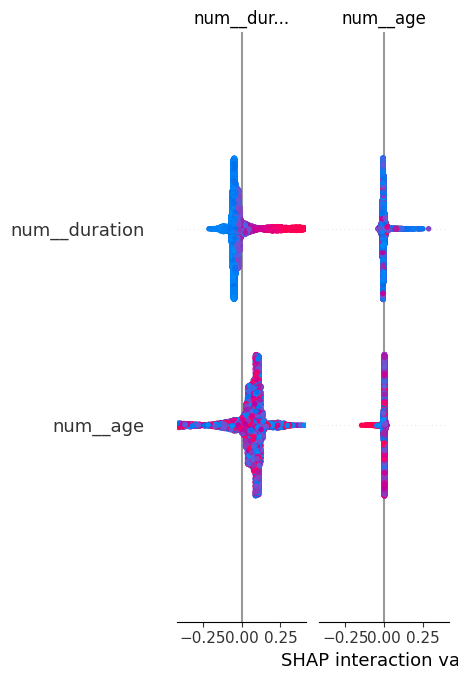

In [21]:
# Global SHAP inportance 
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

# Global SHAP inportance (basewarm plot)
#shap.plot.basewarm(shap_values, max_display=30)

In [ ]:
# Extract SHAP values for positive class (y=1)
shap_pos = shap_values[:,:,1] #shape: (n_samples, n_features)

In [ ]:
# Extract base values for positive class (y=1)
base_pos = shap_values.base_values[:,1] #shape: (n_samples,)

In [ ]:
# Extract corresponding input row
data_pos = shap_values.data #shape: (n_samples, n_features)

In [ ]:
# Build a single-sample explanation
i = 0  # choose sample index

single_explanation = shap.Explanation(
    values = shap_pos[i],
    base_values = base_pos[i],
    data = data_pos[i],
    feature_names = shap_values.feature_names
)


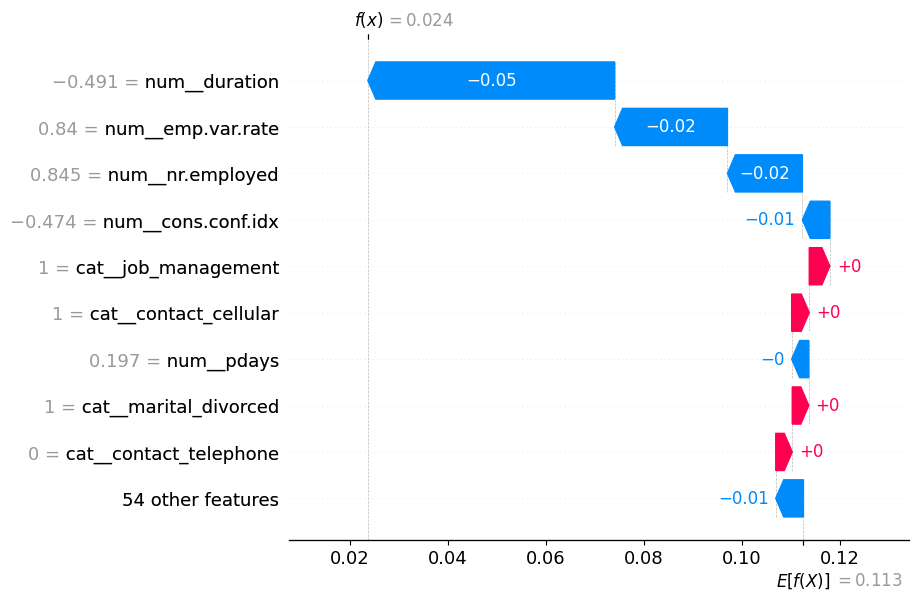

In [32]:
# plot waterfall for the single explanation
shap.plots.waterfall(single_explanation)

In [33]:
# SHAP values structure
shap_values.values.shape

(8238, 63, 2)

8238 = number of samples, 63 = number of features, 2 = number of model outputs 

XGBoost

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

In [36]:
pipe_xgb = Pipeline([
    ('preprocessing', preproc),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

param_grid_xgb = {
    'classifier__n_estimators': [200, 300],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
print("XGB best params:", grid_xgb.best_params_)

y_pred_xgb = best_xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, y_pred_xgb)
print("XGB test ROC-AUC:", xgb_auc)


c:\Users\papak\_Study\DSI\ds_team2_bank_marketing\production-env\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:06:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 300}
XGB test ROC-AUC: 0.9553958913156281


In [ ]:
# Compare Random Forest and XGBoost SHAP values
shap_values_rf = explainer.shap_values(X_test_transformed)
shap.summary_plot(shap_values_rf, X_test_transformed, feature_names=feature_names)

In [ ]:
# Escape running SHAP for XGBoost due to time constraints:
best_xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    learning_rate=0.05,
    max_depth=5,
    n_estimators=300
)


In [30]:
best_xgb = Pipeline([
    ('preprocessing', preproc),
    ('classifier', best_xgb_model)
])


In [31]:
best_xgb.fit(X_train, y_train)


c:\Users\papak\_Study\DSI\ds_team2_bank_marketing\production-env\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:47:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
print("Random Forest AUC:", rf_auc)
print("XGBoost AUC:", xgb_auc)


Random Forest AUC: 0.9496731862351997
XGBoost AUC: 0.9553958913156281


In [33]:

best_model = best_xgb if xgb_auc >= rf_auc else best_rf
print("Chosen model for SHAP:", type(best_model.named_steps['classifier']).__name__)


Chosen model for SHAP: XGBClassifier
